# Prediction Confusion Matrix

In [13]:
import pandas as pd
from pathlib import Path

def collect_prediction_trajectory(
    run_name,
    epochs=range(110, 301, 10),
    run_times=range(1, 9),
    base_dir="./pred_outputs"
):
    """
    Collect prediction csv files across epochs and runs,
    append metadata columns, and concatenate into one DataFrame.
    """

    integrated_df = []

    for epoch in epochs:
        for run_time in run_times:

            csv_path = (
                Path(base_dir)
                / run_name
                / str(run_time)
                / f"pred_E{epoch}_L2.csv"
            )

            if not csv_path.exists():
                print(f"Missing: {csv_path}")
                continue

            # load csv
            df = pd.read_csv(csv_path)

            df = df[["uid", "vowel", "predicted"]].copy()
            df = df.rename(columns={"vowel": "target"})

            # append metadata
            df["epoch"] = epoch
            df["run"] = run_time
            df["run_name"] = run_name

            integrated_df.append(df)

    if len(integrated_df) == 0:
        raise ValueError("No csv files loaded.")

    integrated_df = pd.concat(
        integrated_df,
        ignore_index=True
    )

    return integrated_df

In [14]:
run_name = "0502_RCCL_EQL_EWCp3_1e4_HID4"

integrated_df = collect_prediction_trajectory(run_name)

In [ ]:
integrated_df

,uid,target,predicted,epoch,run,run_name
0,ses_0001,e,ih,110,1,0502_RCCL_EQL_EWCp3_1e4_HID4
1,ses_0002,e,e,110,1,0502_RCCL_EQL_EWCp3_1e4_HID4
2,ses_0003,e,e,110,1,0502_RCCL_EQL_EWCp3_1e4_HID4
3,ses_0004,e,ih,110,1,0502_RCCL_EQL_EWCp3_1e4_HID4
4,ses_0005,e,e,110,1,0502_RCCL_EQL_EWCp3_1e4_HID4
...,...,...,...,...,...,...
12799995,suhLs_7996,uhL,u,300,8,0502_RCCL_EQL_EWCp3_1e4_HID4
12799996,suhLs_7997,uhL,u,300,8,0502_RCCL_EQL_EWCp3_1e4_HID4
12799997,suhLs_7998,uhL,u,300,8,0502_RCCL_EQL_EWCp3_1e4_HID4
12799998,suhLs_7999,uhL,u,300,8,0502_RCCL_EQL_EWCp3_1e4_HID4


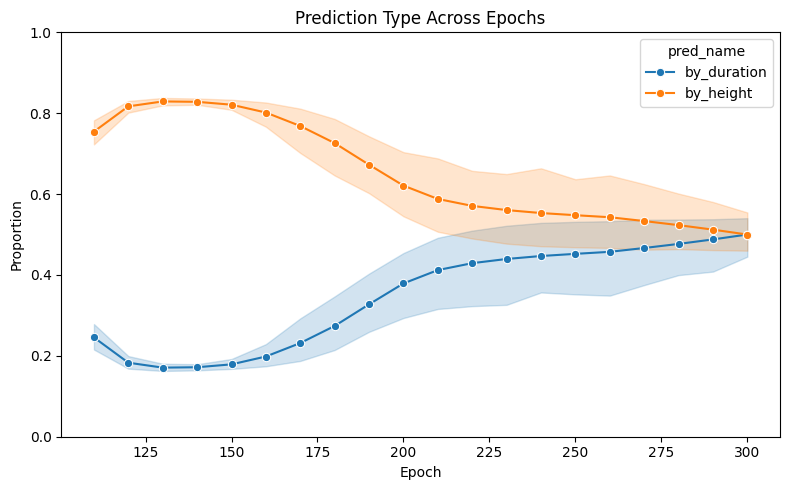

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

def name_prediction_type(row):
    target = row["target"]
    pred = row["predicted"]

    decision_map = {
        ("iS", "i"): "by_height",
        ("iS", "ih"): "by_duration",
        ("ihL", "ih"): "by_height",
        ("ihL", "i"): "by_duration",

        ("uS", "u"): "by_height",
        ("uS", "uh"): "by_duration",
        ("uhL", "uh"): "by_height",
        ("uhL", "u"): "by_duration",
    }

    return decision_map.get((target, pred), "other")


integrated_df["pred_name"] = integrated_df.apply(
    name_prediction_type,
    axis=1
)

# keep only interpretable cases
plot_df = integrated_df[
    integrated_df["pred_name"].isin(["by_duration", "by_height"])
].copy()

# proportion per run × epoch × name
summary = (
    plot_df
    .groupby(["run", "epoch", "pred_name"])
    .size()
    .reset_index(name="count")
)

summary["proportion"] = (
    summary["count"]
    / summary.groupby(["run", "epoch"])["count"].transform("sum")
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=summary,
    x="epoch",
    y="proportion",
    hue="pred_name",
    errorbar=("ci", 95),
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Proportion")
plt.title("Prediction Type Across Epochs")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [21]:
run_name = "0502_RCCL_EQL_EWCp6_1e4_HID4"

integrated_df = collect_prediction_trajectory(run_name, run_times=range(1, 7))

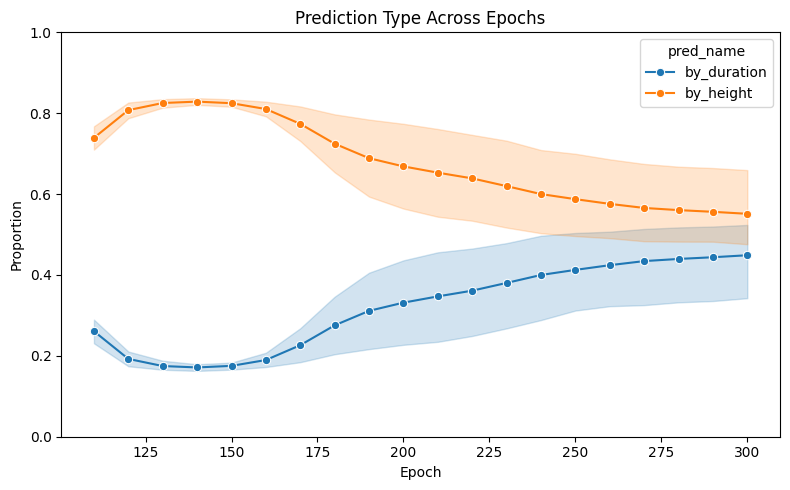

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

def name_prediction_type(row):
    target = row["target"]
    pred = row["predicted"]

    decision_map = {
        ("iS", "i"): "by_height",
        ("iS", "ih"): "by_duration",
        ("ihL", "ih"): "by_height",
        ("ihL", "i"): "by_duration",

        ("uS", "u"): "by_height",
        ("uS", "uh"): "by_duration",
        ("uhL", "uh"): "by_height",
        ("uhL", "u"): "by_duration",
    }

    return decision_map.get((target, pred), "other")


integrated_df["pred_name"] = integrated_df.apply(
    name_prediction_type,
    axis=1
)

# keep only interpretable cases
plot_df = integrated_df[
    integrated_df["pred_name"].isin(["by_duration", "by_height"])
].copy()

# proportion per run × epoch × name
summary = (
    plot_df
    .groupby(["run", "epoch", "pred_name"])
    .size()
    .reset_index(name="count")
)

summary["proportion"] = (
    summary["count"]
    / summary.groupby(["run", "epoch"])["count"].transform("sum")
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=summary,
    x="epoch",
    y="proportion",
    hue="pred_name",
    errorbar=("ci", 95),
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Proportion")
plt.title("Prediction Type Across Epochs")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()